In [1]:
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import T5Tokenizer, T5ForConditionalGeneration
from datasets import load_dataset, concatenate_datasets
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

✅ GPU: NVIDIA GeForce RTX 5060 Ti


In [2]:
MODEL_PATH = "./flan-t5-sentiment-model"

print("⏳ Cargando modelo fine-tuneado...")
tokenizer = T5Tokenizer.from_pretrained(MODEL_PATH)
model = T5ForConditionalGeneration.from_pretrained(MODEL_PATH, torch_dtype=torch.float32)
model = model.to("cuda")
model.eval()

print("✅ Modelo fine-tuneado cargado")

⏳ Cargando modelo fine-tuneado...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


✅ Modelo fine-tuneado cargado


In [3]:
def predict_sentiment(text, max_input_length=512):
    prompt = f"Classify the sentiment of this movie review as 'positive' or 'negative':\n\n{text}"
    
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        max_length=max_input_length,
        truncation=True
    ).to("cuda")
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10
        )
    
    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True).strip().lower()
    
    if "positive" in prediction:
        return 1
    elif "negative" in prediction:
        return 0
    else:
        return -1

print("✅ Función de predicción lista")

✅ Función de predicción lista


In [4]:
ejemplos = [
    "This movie was absolutely amazing! The acting was superb and the story kept me hooked.",
    "Terrible film. Boring, slow, and a complete waste of time. I want my money back.",
    "One of the best movies I have ever seen. A masterpiece of cinema.",
    "The worst movie of the year. Awful script and horrible acting."
]

print("🎬 PRUEBAS MANUALES CON MODELO FINE-TUNEADO\n")
for texto in ejemplos:
    resultado = predict_sentiment(texto)
    emoji = "✅ Positivo" if resultado == 1 else "❌ Negativo" if resultado == 0 else "❓ Indefinido"
    print(f"Reseña: {texto[:80]}...")
    print(f"Resultado: {emoji}\n")

🎬 PRUEBAS MANUALES CON MODELO FINE-TUNEADO

Reseña: This movie was absolutely amazing! The acting was superb and the story kept me h...
Resultado: ✅ Positivo

Reseña: Terrible film. Boring, slow, and a complete waste of time. I want my money back....
Resultado: ❌ Negativo

Reseña: One of the best movies I have ever seen. A masterpiece of cinema....
Resultado: ✅ Positivo

Reseña: The worst movie of the year. Awful script and horrible acting....
Resultado: ❌ Negativo



In [5]:
dataset = load_dataset("stanfordnlp/imdb")

positivas = dataset["test"].filter(lambda x: x["label"] == 1).select(range(100))
negativas = dataset["test"].filter(lambda x: x["label"] == 0).select(range(100))
muestra = concatenate_datasets([positivas, negativas])

print("⏳ Evaluando modelo fine-tuneado con 200 ejemplos...")

y_true = []
y_pred = []

for i, ejemplo in enumerate(muestra):
    pred = predict_sentiment(ejemplo["text"])
    y_true.append(ejemplo["label"])
    y_pred.append(pred if pred != -1 else 0)
    
    if (i + 1) % 50 == 0:
        print(f"  Progreso: {i+1}/200")

print("\n✅ Evaluación completa")

⏳ Evaluando modelo fine-tuneado con 200 ejemplos...
  Progreso: 50/200
  Progreso: 100/200
  Progreso: 150/200
  Progreso: 200/200

✅ Evaluación completa


In [6]:
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Cargar métricas del baseline
with open("baseline_metrics.json", "r") as f:
    baseline = json.load(f)

print("📊 COMPARACIÓN BASELINE vs FINE-TUNED")
print(f"{'='*45}")
print(f"{'Métrica':<15} {'Baseline':>10} {'Fine-tuned':>12} {'Mejora':>8}")
print(f"{'='*45}")
print(f"{'Accuracy':<15} {baseline['accuracy']:>10.4f} {accuracy:>12.4f} {(accuracy - baseline['accuracy'])*100:>+7.2f}%")
print(f"{'F1 Score':<15} {baseline['f1']:>10.4f} {f1:>12.4f} {(f1 - baseline['f1']):>+8.4f}")
print(f"{'='*45}")

print("\nReporte detallado:")
print(classification_report(y_true, y_pred, target_names=["Negativo", "Positivo"]))

# Guardar métricas
finetuned_metrics = {"accuracy": accuracy, "f1": f1}
with open("finetuned_metrics.json", "w") as f:
    json.dump(finetuned_metrics, f)
print("✅ Métricas guardadas")

📊 COMPARACIÓN BASELINE vs FINE-TUNED
Métrica           Baseline   Fine-tuned   Mejora
Accuracy            0.9350       0.9600   +2.50%
F1 Score            0.9372       0.9596  +0.0224

Reporte detallado:
              precision    recall  f1-score   support

    Negativo       0.95      0.97      0.96       100
    Positivo       0.97      0.95      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

✅ Métricas guardadas


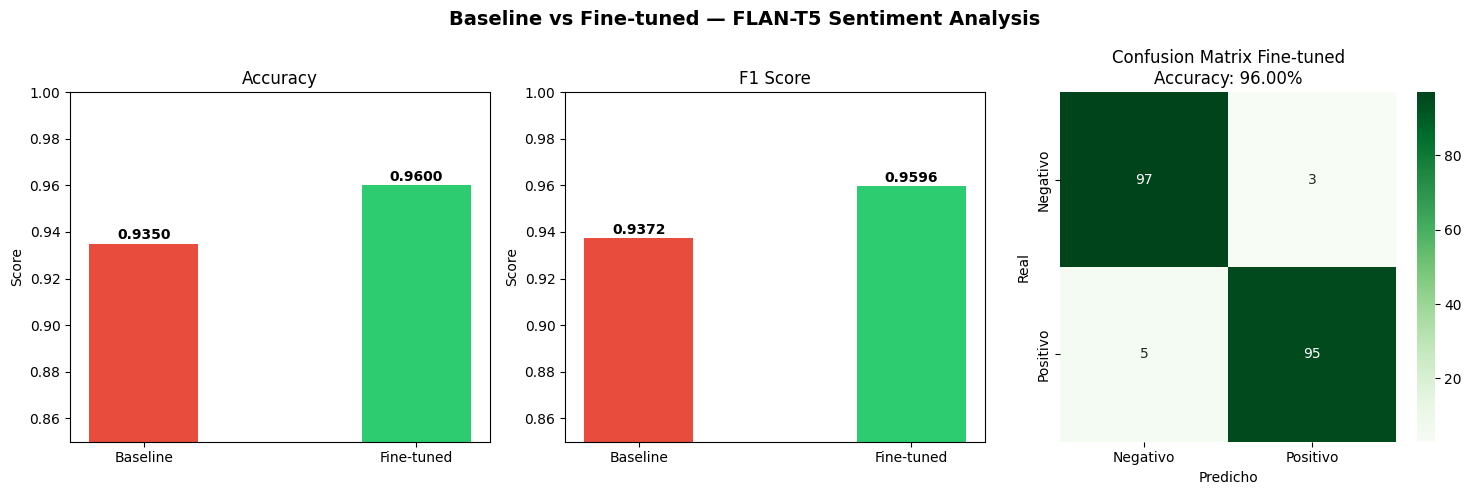

✅ Gráfica guardada


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfica 1 — Accuracy
metricas = ["Baseline", "Fine-tuned"]
accuracies = [baseline["accuracy"], accuracy]
bars = axes[0].bar(metricas, accuracies, color=["#e74c3c", "#2ecc71"], width=0.4)
axes[0].set_ylim(0.85, 1.0)
axes[0].set_title("Accuracy")
axes[0].set_ylabel("Score")
for bar, val in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", fontweight="bold")

# Gráfica 2 — F1 Score
f1s = [baseline["f1"], f1]
bars2 = axes[1].bar(metricas, f1s, color=["#e74c3c", "#2ecc71"], width=0.4)
axes[1].set_ylim(0.85, 1.0)
axes[1].set_title("F1 Score")
axes[1].set_ylabel("Score")
for bar, val in zip(bars2, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", fontweight="bold")

# Gráfica 3 — Confusion Matrix Fine-tuned
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Negativo", "Positivo"],
            yticklabels=["Negativo", "Positivo"],
            ax=axes[2])
axes[2].set_title(f"Confusion Matrix Fine-tuned\nAccuracy: {accuracy*100:.2f}%")
axes[2].set_ylabel("Real")
axes[2].set_xlabel("Predicho")

plt.suptitle("Baseline vs Fine-tuned — FLAN-T5 Sentiment Analysis", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("comparacion_baseline_vs_finetuned.png")
plt.show()
print("✅ Gráfica guardada")

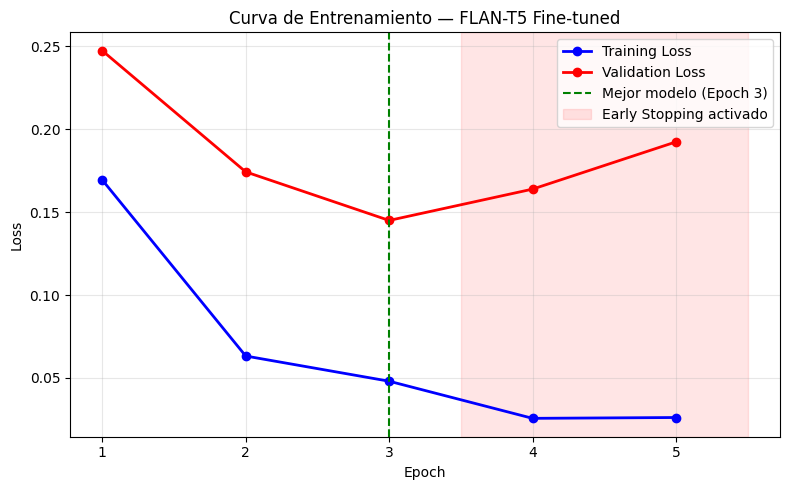

✅ Curva de entrenamiento guardada


In [8]:
epochs = [1, 2, 3, 4, 5]
train_loss = [0.1694, 0.0632, 0.0480, 0.0256, 0.0261]
val_loss = [0.2474, 0.1743, 0.1450, 0.1639, 0.1924]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, "b-o", label="Training Loss", linewidth=2)
plt.plot(epochs, val_loss, "r-o", label="Validation Loss", linewidth=2)
plt.axvline(x=3, color="green", linestyle="--", label="Mejor modelo (Epoch 3)")
plt.axvspan(3.5, 5.5, alpha=0.1, color="red", label="Early Stopping activado")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curva de Entrenamiento — FLAN-T5 Fine-tuned")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("curva_entrenamiento.png")
plt.show()
print("✅ Curva de entrenamiento guardada")